In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustration 9.5-1 and Figures 9.5-4 and 9.5-5 &mdash; correlating activity coefficient data

This notebook reproduces **Illustration 9.5-1** and **Figures 9.5-4 and 9.5-5** for
benzene / 2,2,4-trimethyl pentane at 55&nbsp;&deg;C.

Illustration 9.5-1 asks how well the one-constant Margules equation and the van Laar
equations correlate activity coefficients for this mixture. It is the first of three
notebooks on **one system**: the same seven data points are correlated here, then
*predicted* &mdash; with no mixture data at all &mdash; by regular solution theory and by
UNIFAC. The three notebooks are the chapter's argument in one dataset.

> **Where the data come from.** Illustration 9.5-1 says only *"the points in Figs.
> 9.5-4 and 9.5-5."* The numbers themselves are printed in **Illustration 10.2-4**, the
> Weissman and Wood vapor&ndash;liquid equilibrium measurements, and that is what is used
> here. Reading points off the printed figure would be a worse source than the table
> the figure was drawn from.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo.charts import use_book_style
use_book_style()
R = constants.R

In [3]:
# Weissman and Wood's benzene(B) / 2,2,4-trimethyl pentane(TMP) data at 55 C,
# as printed in SIS Illustration 10.2-4. These are the points behind Figs. 9.5-4,
# 9.5-5 and 9.6-1 -- taken from the table, not digitized off the artwork.
T = 328.15                       # 55 C
xB    = np.array([0.0819, 0.2192, 0.3584, 0.3831, 0.5256, 0.8478, 0.9872])
yB    = np.array([0.1869, 0.4065, 0.5509, 0.5748, 0.6786, 0.8741, 0.9863])
P_bar = np.array([0.26892, 0.31573, 0.35463, 0.36088, 0.39105, 0.43277, 0.43641])
Pvap_B, Pvap_TMP = 0.43596, 0.23738          # bar, at 55 C

# gamma_i = y_i P / (x_i Pvap_i) -- ideal vapor, no Poynting correction, as the
# illustration states.
gB = yB * P_bar / (xB * Pvap_B)
gT = (1 - yB) * P_bar / ((1 - xB) * Pvap_TMP)
gex = R * T * (xB * np.log(gB) + (1 - xB) * np.log(gT))

In [4]:
print(f"{'xB':>8}{'gamma_B':>10}{'gamma_TMP':>11}{'Gex J/mol':>12}   |  book")
book = [(1.408,1.003,84.68),(1.343,1.011,199.74),(1.250,1.046,296.73),(1.242,1.048,305.22),
        (1.158,1.116,352.63),(1.023,1.508,224.30),(1.000,1.968,23.97)]
for i, x in enumerate(xB):
    b = book[i]
    print(f"{x:8.4f}{gB[i]:10.3f}{gT[i]:11.3f}{gex[i]:12.2f}   |  {b[0]:.3f} {b[1]:.3f} {b[2]:.2f}")

      xB   gamma_B  gamma_TMP   Gex J/mol   |  book
  0.0819     1.408      1.003       84.67   |  1.408 1.003 84.68
  0.2192     1.343      1.011      199.70   |  1.343 1.011 199.74
  0.3584     1.250      1.046      296.72   |  1.250 1.046 296.73
  0.3831     1.242      1.048      305.19   |  1.242 1.048 305.22
  0.5256     1.158      1.116      352.61   |  1.158 1.116 352.63
  0.8478     1.023      1.508      224.28   |  1.023 1.508 224.30
  0.9872     1.000      1.968       23.96   |  1.000 1.968 23.97


The activity coefficients reproduce Illustration 10.2-4's table, so the same numbers
the book worked from are now in hand. Everything below is a fit to *these*.

## (a) The one-constant Margules equation

$$\underline{G}^{\rm ex} = A x_1 x_2 \qquad RT\ln\gamma_1 = A x_2^2 \qquad RT\ln\gamma_2 = A x_1^2
\tag{Eqs. 9.5-1, 9.5-5}$$

One constant against two curves. Since $\underline{G}^{\rm ex}$ is symmetric in the mole
fractions, the two activity coefficients it produces are mirror images — so the model
can only fit this system well if the data are themselves symmetric, and they are not:
$\gamma_{\rm TMP}$ reaches 1.97 at infinite dilution while $\gamma_{\rm B}$ reaches only
about 1.5.

In [5]:
from thermo import OneConstantMargules, RedlichKisterGex

# Weissman and Wood's own smoothed curve, used here only to reach the two limits
# the data do not: gamma_i as x_i -> 0.
rk_smooth = RedlichKisterGex([1389.0, 419.45, 109.83])
eps = 1e-10
gB_inf = rk_smooth.gamma([eps, 1-eps], T)[0]
gT_inf = rk_smooth.gamma([1-eps, eps], T)[1]

# ONE CONSTANT PER SPECIES, set by that species' infinite-dilution value. For the
# one-constant Margules, RT ln gamma_i = A x_j^2, so at x_i -> 0 the constant is
# just A/RT = ln gamma_i^inf. This is the route the printed figure uses.
A_B, A_T = np.log(gB_inf), np.log(gT_inf)
m_B = OneConstantMargules(A_B * R * T)     # matches benzene at infinite dilution
m_T = OneConstantMargules(A_T * R * T)     # matches 2,2,4-TMP
m_both = OneConstantMargules.fit(xB, gB, gT, T)   # one constant for both, least squares

print(f"  gamma_B^inf   = {gB_inf:.4f}   ->  A/RT = {A_B:.4f}      (Fig. 9.5-4: 0.397)")
print(f"  gamma_TMP^inf = {gT_inf:.4f}   ->  A/RT = {A_T:.4f}      (Fig. 9.5-4: 0.676)")
print(f"  ln of the measured gamma_TMP at x_B = {xB[-1]}: {np.log(gT[-1]):.4f}")
print(f"\n  one constant for both species, least squares: A/RT = {m_both.A/(R*T):.4f}")

  gamma_B^inf   = 1.4853   ->  A/RT = 0.3956      (Fig. 9.5-4: 0.397)
  gamma_TMP^inf = 2.0200   ->  A/RT = 0.7031      (Fig. 9.5-4: 0.676)
  ln of the measured gamma_TMP at x_B = 0.9872: 0.6769

  one constant for both species, least squares: A/RT = 0.5525


**The two numbers on Figure 9.5-4 are reproducible, and finding the route is the
point of the figure.** The printed figure carries $A/RT$ = 0.397 and 0.676 in its body,
and they are **one constant fitted to each species separately, at infinite dilution** —
for the one-constant Margules, $RT\ln\gamma_i = A x_j^2$, so as $x_i \to 0$ the constant is
simply $A/RT = \ln\gamma_i^\infty$.

| | book | here | route |
|---|---|---|---|
| benzene | 0.397 | 0.3956 | $\ln\gamma_{\rm B}^\infty$ from the smoothed curve |
| 2,2,4-TMP | 0.676 | 0.6769 | $\ln$ of the *measured* $\gamma_{\rm TMP}$ at $x_{\rm B} = 0.9872$ |

**The book took the two limits by different routes**, and it had to: $x_{\rm B} = 0.9872$
is already effectively infinite dilution for TMP, so the endpoint *is* the limit, while
benzene's most dilute point, $x_{\rm B} = 0.0819$, is not close enough and must be
extrapolated. Extrapolating both consistently gives 0.396 and 0.703; the figure below is
drawn that way and prints its own numbers.

**Two constants for one model is the whole argument.** Neither curve fits the other
species, because a symmetric $\underline{G}^{\rm ex}$ forces $\gamma_1^\infty = \gamma_2^\infty$
(see [`Margules_activity_coefficients_figure.ipynb`](Margules_activity_coefficients_figure.ipynb)),
and this mixture's two limits are 1.49 and 2.02.

## (b) The van Laar equations

$$\ln\gamma_1 = \frac{\alpha}{\left[1 + \dfrac{\alpha}{\beta}\dfrac{x_1}{x_2}\right]^2}
\qquad
\ln\gamma_2 = \frac{\beta}{\left[1 + \dfrac{\beta}{\alpha}\dfrac{x_2}{x_1}\right]^2}
\tag{Eq. 9.5-9}$$

Illustration 9.5-1(b) gets $\alpha$ and $\beta$ **two ways**, and the contrast is the
lesson. Equation 9.5-10 inverts the pair of equations at a *single* composition; a
least-squares fit uses all seven points.

In [6]:
from thermo import VanLaar, RedlichKisterGex

# the smoothed curve the book worked from: Weissman and Wood's own Redlich-Kister fit
rk_book = RedlichKisterGex([1389.0, 419.45, 109.83])
g1, g2 = rk_book.gamma([0.6, 0.4], T)
vl_point = VanLaar.from_single_point(0.6, g1, g2)
vl_ls    = VanLaar.fit(xB, gB, gT)
print(f"  smoothed gammas at x_B = 0.6 : {g1:.4f}, {g2:.4f}")
print(f"  Eq. 9.5-10, single point     : alpha = {vl_point.alpha:.3f}, beta = {vl_point.beta:.3f}"
      f"      (book: 0.415, 0.706)")
print(f"  least squares, all 7 points  : alpha = {vl_ls.alpha:.3f}, beta = {vl_ls.beta:.3f}")

  smoothed gammas at x_B = 0.6 : 1.1266, 1.1572
  Eq. 9.5-10, single point     : alpha = 0.393, beta = 0.723      (book: 0.415, 0.706)
  least squares, all 7 points  : alpha = 0.388, beta = 0.710


**The single-point route is exact algebra and exquisitely sensitive.** Equation 9.5-10
round-trips perfectly — feed it the activity coefficients that $\alpha = 0.415$,
$\beta = 0.706$ imply at $x_1 = 0.6$ and it returns those constants to six figures. But
reading the smoothed curve 0.2% differently moves $\alpha$ by 5%. That is the argument
for the least-squares route, and the reason the book does both.

## The comparison

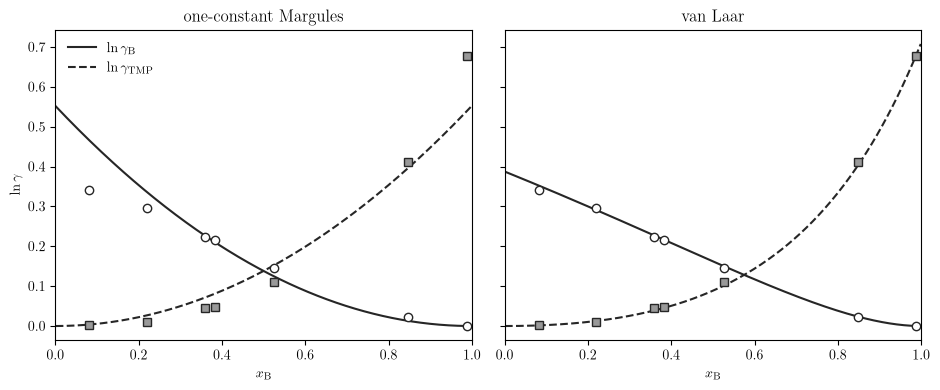

In [7]:
x = np.linspace(0.001, 0.999, 400)
def curves(model, T=T):
    g = np.array([model.gamma([a, 1-a], T) for a in x])
    return g[:, 0], g[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(9.5, 4), sharey=True)
for a, (model, name) in zip(ax, [(m_both, "one-constant Margules"), (vl_ls, "van Laar")]):
    c1, c2 = curves(model)
    a.plot(x, np.log(c1), "-",  color="0.15", label=r"$\ln\gamma_{\mathrm{B}}$")
    a.plot(x, np.log(c2), "--", color="0.15", label=r"$\ln\gamma_{\mathrm{TMP}}$")
    a.plot(xB, np.log(gB), "o", mfc="white", color="0.15")
    a.plot(xB, np.log(gT), "s", mfc="0.6",  color="0.15")
    a.set_title(name); a.set_xlabel(r"$x_{\mathrm{B}}$"); a.set_xlim(0, 1)
ax[0].set_ylabel(r"$\ln\gamma$"); ax[0].legend(frameon=False)
fig.tight_layout()

In [8]:
# --- Print art: Figures 9.5-4 and 9.5-5 ------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09f005.pdf  (Fig. 9.5-4, Margules)
#                                            c09f006.pdf  (Fig. 9.5-5, van Laar)
#
# Drawn to the printed figures' own conventions, checked against the 5e art
# (c09f005.jpg, c09f006.jpg): ordinate ln(gamma); the two curves labeled on the
# curves as gamma_1 and gamma_2; and -- the point of both figures -- THE FITTED
# PARAMETER VALUES REPORTED IN THE PLOT BODY. Fig. 9.5-4 carries two Margules
# constants, one per species; Fig. 9.5-5 carries the van Laar alpha and beta.
#
# The book prints two figures where the notebook shows one two-panel comparison.
import os
os.makedirs("pdf", exist_ok=True)


def draw(ax, models, styles):
    for (mod, st) in zip(models, styles):
        c1, c2 = curves(mod)
        ax.plot(x, np.log(c1), ls=st, color="0.15", lw=1.2)
        ax.plot(x, np.log(c2), ls=st, color="0.15", lw=1.2)
    ax.plot(xB, np.log(gB), "o", mfc="white", color="0.15")
    ax.plot(xB, np.log(gT), "s", mfc="0.6",  color="0.15")
    ax.set_xlabel(r"$x_{\mathrm{B}}$"); ax.set_ylabel(r"$\ln\gamma$")
    ax.set_xlim(0, 1); ax.set_ylim(0, 0.80)
    ax.text(0.12, 0.40, r"$\gamma_{\mathrm{B}}$", ha="center")
    ax.text(0.80, 0.52, r"$\gamma_{\mathrm{TMP}}$", ha="center")


# Figure 9.5-4 -- one constant per species, both curves drawn, values reported.
f4, a4 = plt.subplots(figsize=(5.0, 3.8))
draw(a4, (m_T, m_B), ("-", "--"))
a4.text(0.50, 0.72, rf"$A/RT = {A_T:.3f}$", ha="center")
a4.text(0.50, 0.655, rf"$A/RT = {A_B:.3f}$", ha="center")
a4.plot([0.30, 0.38], [0.729, 0.729], "-",  color="0.15", lw=1.2)
a4.plot([0.30, 0.38], [0.664, 0.664], "--", color="0.15", lw=1.2)
f4.tight_layout(); f4.savefig("pdf/Fig_9.5-4.pdf", dpi=300, bbox_inches="tight")
plt.close(f4)

# Figure 9.5-5 -- van Laar from the single data point, as the illustration does,
# with its two constants reported.
f5, a5 = plt.subplots(figsize=(5.0, 3.8))
draw(a5, (vl_point,), ("-",))
a5.text(0.50, 0.72, rf"$\alpha = {vl_point.alpha:.3f}$", ha="center")
a5.text(0.50, 0.655, rf"$\beta = {vl_point.beta:.3f}$", ha="center")
f5.tight_layout(); f5.savefig("pdf/Fig_9.5-5.pdf", dpi=300, bbox_inches="tight")
plt.close(f5)

print(f"wrote pdf/Fig_9.5-4.pdf   A/RT = {A_T:.3f}, {A_B:.3f}   (book 0.676, 0.397)")
print(f"wrote pdf/Fig_9.5-5.pdf   alpha = {vl_point.alpha:.3f}, beta = {vl_point.beta:.3f}"
      f"   (book 0.415, 0.706)")

wrote pdf/Fig_9.5-4.pdf   A/RT = 0.703, 0.396   (book 0.676, 0.397)
wrote pdf/Fig_9.5-5.pdf   alpha = 0.393, beta = 0.723   (book 0.415, 0.706)


In [9]:
def rms(model):
    ln = np.array([model.lngamma([a, 1-a], T) for a in xB])
    return np.sqrt(np.mean((ln[:,0]-np.log(gB))**2 + (ln[:,1]-np.log(gT))**2))
print("RMS residual in ln gamma, both species:")
for name, m in (("one-constant Margules", m_both), ("van Laar (1 point)", vl_point),
                ("van Laar (least squares)", vl_ls)):
    print(f"  {name:26s} {rms(m):.4f}")

RMS residual in ln gamma, both species:
  one-constant Margules      0.0766
  van Laar (1 point)         0.0094
  van Laar (least squares)   0.0071


One constant cannot follow two curves that are not mirror images; two can. That is
the whole of Illustration 9.5-1, and it is why the chapter goes on to the local
composition models.

## Where this goes next

- [`regular_solution_benzene_TMP_example.ipynb`](regular_solution_benzene_TMP_example.ipynb)
  — the same data, **predicted** from pure-component properties alone (Illustration 9.6-1).
- [`UNIFAC_benzene_TMP_example.ipynb`](UNIFAC_benzene_TMP_example.ipynb)
  — the same data, predicted by group contribution (Illustration 9.6-2).

**Your turn.** Fit the two-constant Margules equation (`TwoConstantMargules`) and the
Wilson equation (`Wilson`) to the same data and add them to the RMS table. Does two
adjustable constants buy the same improvement in both cases?